### What it will be covered?
- Exploratory data analysis
- Data transformation for object detection
- Creating custom datasets
- Creating the model
- Defining the loss, optimizer, and IOU metric
- Training and evaluation of the model
- Deploying the model

### Exploratory Data Analysis

In [85]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pylab as plt

# fix random seed
np.random.seed(2019)
# from matplotlib import rcParams

# figure size in inches
fig, ax = plt.subplots(figsize=(10, 5))
%matplotlib inline

In [86]:
path2data="./data/"

# full path of labels file
path2labels=os.path.join(path2data,"Training400","Fovea_location.xlsx")

# maske sure to install xlrd
labels_df=pd.read_excel(path2labels,index_col="ID")

labels_df.head()

,ImgName,Fovea_X,Fovea_Y
ID,,,
1,g0001.jpg,1057.95,1076.52
2,g0002.jpg,1190.59,1017.09
3,g0003.jpg,1070.56,1084.85
4,g0004.jpg,1072.60,1035.48
5,g0005.jpg,1058.19,1100.33


In [87]:
print(len(labels_df))
labels_df.tail()

400


,ImgName,Fovea_X,Fovea_Y
ID,,,
396,n0356.jpg,1229.73,1043.89
397,n0357.jpg,1080.45,1081.30
398,n0358.jpg,1288.78,1122.37
399,n0359.jpg,1239.17,1077.17
400,n0360.jpg,1237.73,1089.06


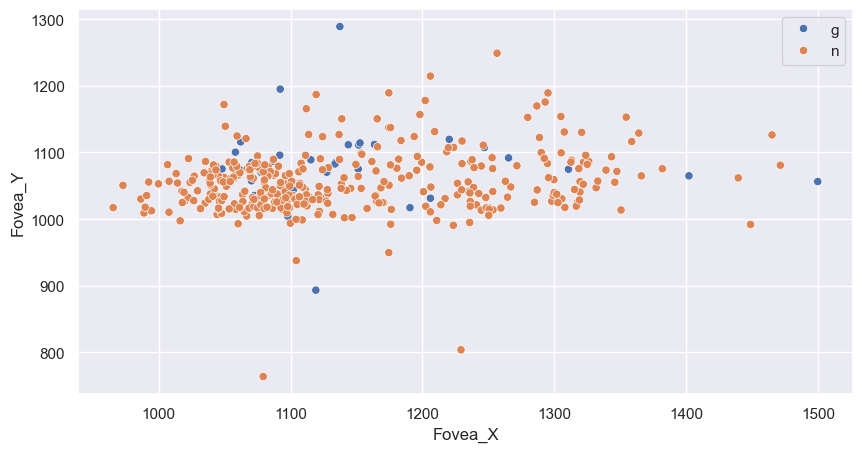

In [88]:
AorN=[imn[0] for imn in labels_df.ImgName]
sns.scatterplot(x=labels_df['Fovea_X'], y=labels_df['Fovea_Y'],hue=AorN)
plt.show()

In [89]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.subplots_adjust(wspace=0, hspace=0.3)
nrows,ncols=2,3

# get imgName column
imgName=labels_df["ImgName"]

# get ids
ids=labels_df.index

# select random ids
rndIds=np.random.choice(ids,nrows*ncols)
print(rndIds)



[ 73 371 160 294 217 191]


In [90]:
def load_img_label(labels_df,id_):    
    imgName=labels_df["ImgName"]    
    # if imgName[id_][0]=="A":
    #     prefix="Glaucoma"
    # else:
    #     prefix="Non-Glaucoma"
            
    fullPath2img=os.path.join(path2data,"Training400\Disc_Cup_Fovea_Illustration",imgName[id_])
    img = Image.open(fullPath2img)
    
    # centroid
    x=labels_df["Fovea_X"][id_]
    y=labels_df["Fovea_Y"][id_]
    
    label=(x,y)
    return img,label

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
C:\Users\maa\AppData\Local\Temp\ipykernel_10592\922121691.py:8: SyntaxWarning: invalid escape sequence '\D'
  fullPath2img=os.path.join(path2data,"Training400\Disc_Cup_Fovea_Illustration",imgName[id_])


In [91]:
def show_img_label(img,label,w_h=(50,50),thickness=2):   
    w,h=w_h                   
    cx,cy=label
    
    # draw a rectangle 
    draw = ImageDraw.Draw(img)
    draw.rectangle(((cx-w/2, cy-h/2), (cx+w/2, cy+h/2)),outline="green",width=thickness)

    plt.imshow(np.asarray(img))

(2124, 2056) (np.float64(1077.9), np.float64(1073.42))
(2124, 2056) (np.float64(1219.67), np.float64(1107.04))
(2124, 2056) (np.float64(1290.1), np.float64(1099.89))
(2124, 2056) (np.float64(1175.79), np.float64(1137.25))
(2124, 2056) (np.float64(1109.19), np.float64(1047.88))
(2124, 2056) (np.float64(1128.37), np.float64(1038.47))


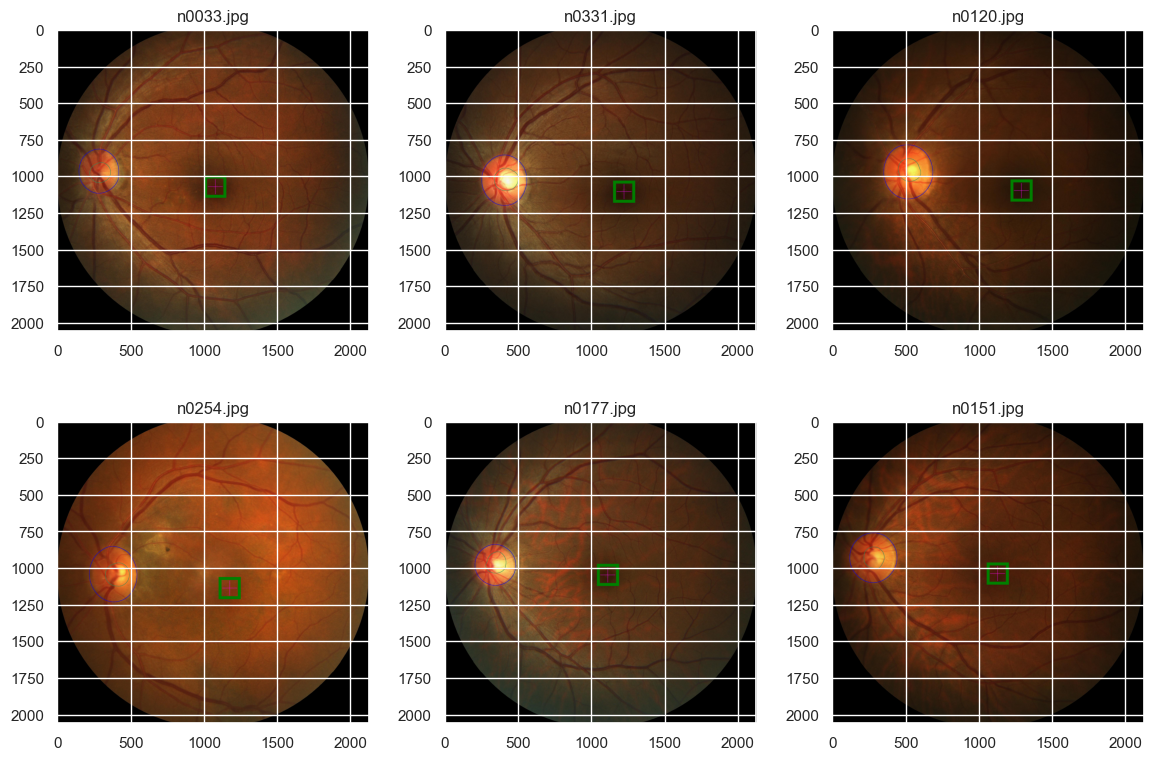

In [92]:
for i,id_ in enumerate(rndIds):
    
    img,label=load_img_label(labels_df,id_)   
    print(img.size,label)
    
    plt.subplot(nrows, ncols, i+1) 
    show_img_label(img,label,w_h=(150,150),thickness=20)
    plt.title(imgName[id_])
plt.show()

In [93]:
h_list,w_list=[],[]

counter=0
for id_ in ids:
    counter=counter+1
    print("{} loop",counter)
    full_path=os.path.join(path2data,"Training400/Disc_Cup_Fovea_Illustration",imgName[id_])

    img=Image.open(full_path)
    h,w=img.size
    h_list.append(h)
    w_list.append(w)

print(h)
print(w)

{} loop 1
{} loop 2
{} loop 3
{} loop 4
{} loop 5
{} loop 6
{} loop 7
{} loop 8
{} loop 9
{} loop 10
{} loop 11
{} loop 12
{} loop 13
{} loop 14
{} loop 15
{} loop 16
{} loop 17
{} loop 18
{} loop 19
{} loop 20
{} loop 21
{} loop 22
{} loop 23
{} loop 24
{} loop 25
{} loop 26
{} loop 27
{} loop 28
{} loop 29
{} loop 30
{} loop 31
{} loop 32
{} loop 33
{} loop 34
{} loop 35
{} loop 36
{} loop 37
{} loop 38
{} loop 39
{} loop 40
{} loop 41
{} loop 42
{} loop 43
{} loop 44
{} loop 45
{} loop 46
{} loop 47
{} loop 48
{} loop 49
{} loop 50
{} loop 51
{} loop 52
{} loop 53
{} loop 54
{} loop 55
{} loop 56
{} loop 57
{} loop 58
{} loop 59
{} loop 60
{} loop 61
{} loop 62
{} loop 63
{} loop 64
{} loop 65
{} loop 66
{} loop 67
{} loop 68
{} loop 69
{} loop 70
{} loop 71
{} loop 72
{} loop 73
{} loop 74
{} loop 75
{} loop 76
{} loop 77
{} loop 78
{} loop 79
{} loop 80
{} loop 81
{} loop 82
{} loop 83
{} loop 84
{} loop 85
{} loop 86
{} loop 87
{} loop 88
{} loop 89
{} loop 90
{} loop 91
{} loop 

C:\Users\maa\AppData\Local\Temp\ipykernel_10592\2760052702.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=h_list, kde=False)


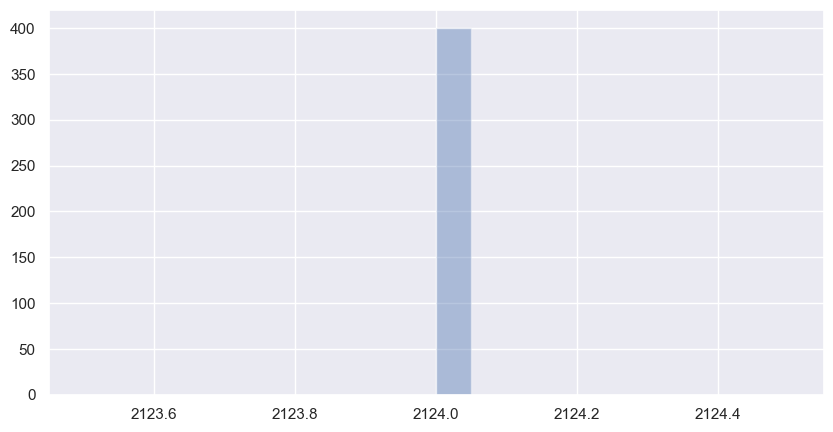

In [98]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.distplot(a=h_list, kde=False)
plt.show()

C:\Users\maa\AppData\Local\Temp\ipykernel_10592\1855833812.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=w_list, kde=False)


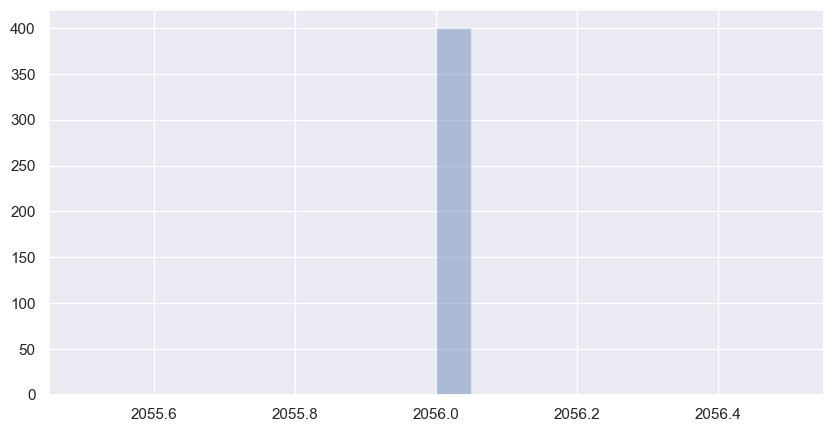

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.distplot(a=w_list, kde=False)
plt.show()